# Creation

Create rasters from scratch

## Settings

In [39]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_nrows <- 100
param_ncols <- 300
param_nlyrs <- 1
param_xmin <- -150
param_xmax <- 150
param_ymin <- -50
param_ymax <- 50
param_crs <- "EPSG:28992"
param_resolutiono <- 1
param_values <- ""
param_names <- ""
param_time <- NULL
param_out <- tempdir()

## Create raster from scratch

In [40]:
# GSTB create raster
# NaaVRE:
#  cell:
#   params:
#    - param_nrows: Integer
#    - param_ncols: Integer
#    - param_nlyrs: Integer
#    - param_xmin: Float
#    - param_xmax: Float
#    - param_ymin: Float
#    - param_ymax: Float
#    - param_crs: String
#    - param_resolution: Float
#    - param_values: List
#    - param_names: List
#    - param_time: List
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Create raster
if(is.null(param_resolution) | (param_resolution == "") | (param_resolution <= 0)) {
  r <- rast(nrows = param_nrows,
            ncols = param_ncols,
            nlyrs = param_nlyrs,
            xmin  = param_xmin,
            xmax  = param_xmax, 
            ymin  = param_ymin,
            ymax  = param_ymax,
            crs   = param_crs)
} else {
  r <- rast(res   = param_resolution,
            nlyrs = param_nlyrs,
            xmin  = param_xmin,
            xmax  = param_xmax, 
            ymin  = param_ymin,
            ymax  = param_ymax,
            crs   = param_crs)
}

# Add values
if(!is.null(param_values) & all(param_values != "") & (length(param_values) > 0)) {
  values(r) <- as.numeric(param_values)
} else {
  values(r) <- 0
}

# Add names
if(!is.null(param_names) & all(param_names != "") & (length(param_names) > 0)) {
  names(r) <- as.character(param_names)
} else {
  names(r) <- NA
}

# Add time
if(!is.null(param_time) & all(param_time != "") & (length(param_time) > 0)) {
  time(r) <- param_time
}

# Save to file
writeRaster(x         = r,
            filename  = paste0(param_out, "/created_raster.tif"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "created_raster.tif",
                  full.names = TRUE)

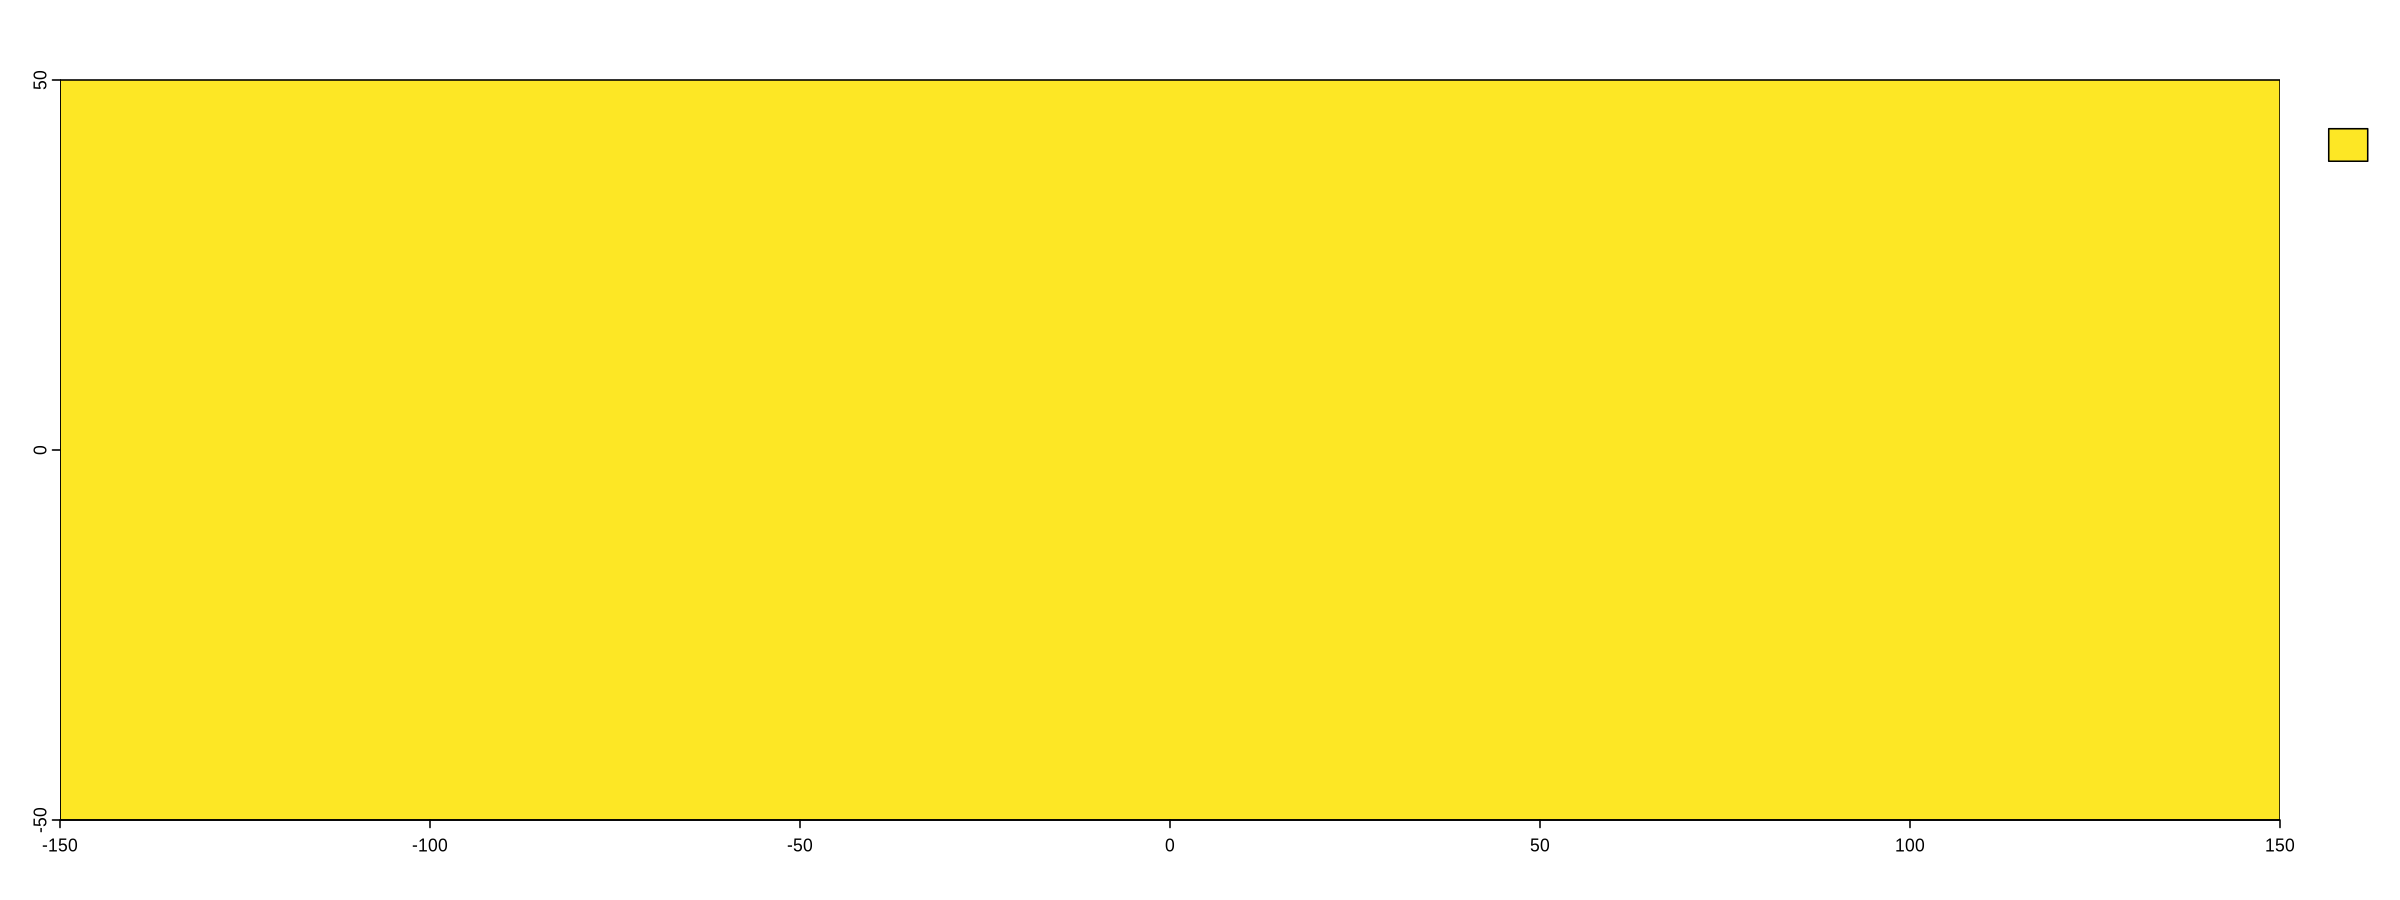

In [41]:
options(repr.plot.width = 16,
        repr.plot.height = 6,
        repr.plot.res = 150)
plot(rast(out))